In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

# Create Dataframe
df = pd.read_csv(r"F:\visa data\EasyVisa.csv")

# Print shape of dataset
print(df.shape)

(25480, 12)


In [48]:
## these are the features with nan value
features_with_na = [features for features in df.columns if df[features].isnull().sum() >= 1]

for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean() * 100, 5), '% missing values')

In [49]:
features_with_na

[]

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.drop('case_id', inplace=True, axis=1)

In [52]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [53]:
from datetime import date
todays_date=date.today()
current_year=todays_date.year


In [54]:
current_year

2026

In [55]:
df['company_age']=current_year-df['yr_of_estab']


In [56]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


In [57]:
#df.drop('year_of_estab', inplace=True, axis=1)
df.drop('yr_of_estab', inplace=True, axis=1)

In [58]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


In [59]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 3


In [60]:
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 8


In [61]:
discrete_features = [feature for feature in num_features if len(df[feature].unique()) <= 25]
print('Num of Discrete Features :', len(discrete_features))

Num of Discrete Features : 0


In [62]:
continuous_features = [feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :', len(continuous_features))

Num of Continuous Features : 3


In [63]:
print("Numerical Features:", num_features)
print("Discrete Features:", discrete_features)
print("Continuous Features:", continuous_features)

Numerical Features: ['no_of_employees', 'prevailing_wage', 'company_age']
Discrete Features: []
Continuous Features: ['no_of_employees', 'prevailing_wage', 'company_age']


In [64]:
x=df.drop('case_status', axis=1)
y=df['case_status']

In [65]:
y.head()

0       Denied
1    Certified
2       Denied
3       Denied
4    Certified
Name: case_status, dtype: object

In [66]:
y=np.where(y=='Denied',0,1)


In [67]:
y

array([0, 1, 0, ..., 1, 1, 1], shape=(25480,))

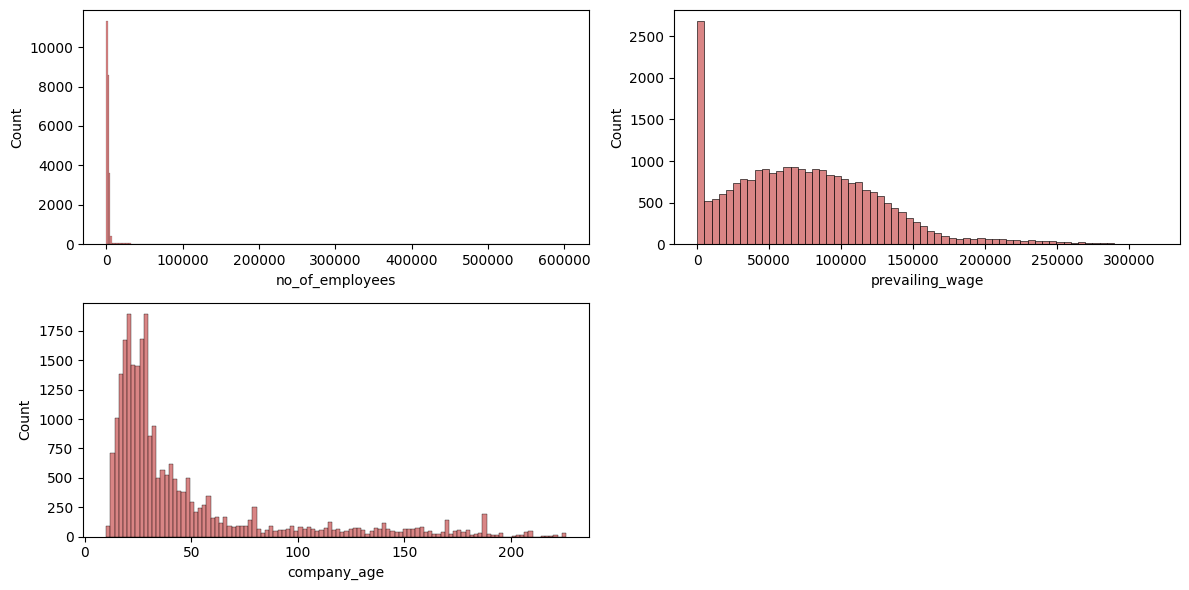

In [68]:
plt.figure(figsize=(12, 6))

for i, col in enumerate(['no_of_employees', 'prevailing_wage', 'company_age']):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=df[col], color='indianred')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [69]:
x[continuous_features].skew(axis=0,skipna=True)

no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

In [70]:
X = df.drop('case_status', axis=1)
y = df['case_status']

In [71]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

transform_features = ['company_age', 'no_of_employees']

X_copy = pt.fit_transform(X[transform_features])
X_copy = pd.DataFrame(X_copy, columns=transform_features)

In [72]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)

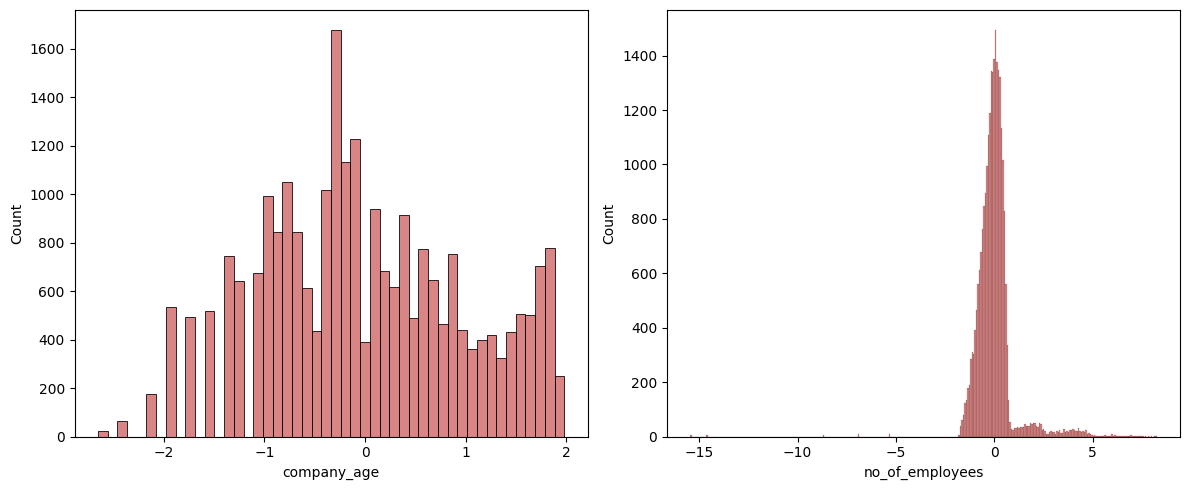

In [73]:
plt.figure(figsize=(12, 5))

for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [74]:
X_copy.skew(axis=0,skipna=True)

company_age        0.120823
no_of_employees    0.399339
dtype: float64

In [75]:
for feature in cat_features:
    print(feature,':', df[feature].nunique())

continent : 6
education_of_employee : 4
has_job_experience : 2
requires_job_training : 2
region_of_employment : 5
unit_of_wage : 4
full_time_position : 2
case_status : 2


In [76]:
num_features=list(X.select_dtypes(exclude='object').columns)

In [77]:
num_features

['no_of_employees', 'prevailing_wage', 'company_age']

In [78]:
# Create Column Transformer with 3 types of transformers

or_columns = ['has_job_experience', 'requires_job_training', 
              'full_time_position', 'education_of_employee']

oh_columns = ['continent', 'unit_of_wage', 'region_of_employment']

transform_columns = ['no_of_employees', 'company_age']


from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()
ordinal_encoder = OrdinalEncoder()


transform_pipe = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson'))
])


preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, oh_columns),
        ("Ordinal_Encoder", ordinal_encoder, or_columns),
        ("Transformer", transform_pipe, transform_columns),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [79]:
X=preprocessor.fit_transform(X)

In [80]:
X

array([[ 0.        ,  1.        ,  0.        , ...,  0.38666657,
        -1.39853722, -0.65122993],
       [ 0.        ,  1.        ,  0.        , ..., -0.14228155,
         0.1698353 , -0.53321103],
       [ 0.        ,  1.        ,  0.        , ...,  1.69498375,
         0.91907852, -0.6748337 ],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.19871259,
         1.36027953,  1.63833662],
       [ 0.        ,  1.        ,  0.        , ..., -0.16387483,
         0.22150859,  2.18122353],
       [ 0.        ,  1.        ,  0.        , ..., -0.10805575,
        -0.06776315,  0.45814768]], shape=(25480, 24))

In [81]:
from imblearn.combine import SMOTETomek, SMOTEENN

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTEENN(random_state=42, sampling_strategy='minority')

# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X, y)

In [82]:
from sklearn.model_selection import train_test_split

# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((13644, 24), (3412, 24))

In [83]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [84]:
def evaluate_clf(true, predicted, prob):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    roc_auc = roc_auc_score(true, prob)

    return acc, f1, precision, recall, roc_auc

In [85]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(),
    "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "Support Vector Classifier": SVC(probability=True),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [86]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_res = le.fit_transform(y_res)

In [87]:
y_res[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [88]:
def evaluate_models(X, y, models):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models_list = []
    accuracy_list = []
    auc = []

    for i in range(len(models)):

        model = list(models.values())[i]
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Probabilities (for ROC AUC)
        if hasattr(model, "predict_proba"):
            y_train_prob = model.predict_proba(X_train)[:, 1]
            y_test_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_train_prob = y_train_pred
            y_test_prob = y_test_pred

        # Training performance
        model_train_accuracy, model_train_f1, model_train_precision, \
        model_train_recall, model_train_rocauc_score = evaluate_clf(
            y_train, y_train_pred, y_train_prob
        )

        # Test performance
        model_test_accuracy, model_test_f1, model_test_precision, \
        model_test_recall, model_test_rocauc_score = evaluate_clf(
            y_test, y_test_pred, y_test_prob )

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print("- F1 score: {:.4f}".format(model_train_f1))
        print("- Precision: {:.4f}".format(model_train_precision))
        print("- Recall: {:.4f}".format(model_train_recall))
        print("- Roc Auc Score: {:.4f}".format(model_train_rocauc_score))

        print('Model performance for Test set')
        print("- Accuracy: {:.4f}".format(model_test_accuracy))
        print("- F1 score: {:.4f}".format(model_test_f1))
        print("- Precision: {:.4f}".format(model_test_precision))
        print("- Recall: {:.4f}".format(model_test_recall))
        print("- Roc Auc Score: {:.4f}".format(model_test_rocauc_score))

        accuracy_list.append(model_test_accuracy)
        auc.append(model_test_rocauc_score)

        print("=" * 35)
        print("\n")

    report = pd.DataFrame(
        list(zip(models_list, accuracy_list)),
        columns=['Model Name', 'Accuracy']
    ).sort_values(by='Accuracy', ascending=False)

    return report

In [89]:
base_model_report = evaluate_models(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
Model performance for Test set
- Accuracy: 0.9505
- F1 score: 0.9543
- Precision: 0.9530
- Recall: 0.9556
- Roc Auc Score: 0.9893


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
Model performance for Test set
- Accuracy: 0.9220
- F1 score: 0.9279
- Precision: 0.9289
- Recall: 0.9269
- Roc Auc Score: 0.9216


Gradient Boosting
Model performance for Training set
- Accuracy: 0.8860
- F1 score: 0.8944
- Precision: 0.8941
- Recall: 0.8946
- Roc Auc Score: 0.9590
Model performance for Test set
- Accuracy: 0.8933
- F1 score: 0.9011
- Precision: 0.9040
- Recall: 0.8982
- Roc Auc Score: 0.9622


Logistic Regression
Model performance for Training set
- Accuracy: 0.7375
- F1 score: 0.7528
- Precision: 0.7655
- Recall: 0.7406
- Roc Auc Score: 0.8243
Mo

In [90]:
base_model_report

,Model Name,Accuracy
0,Random Forest,0.950469
4,K-Neighbors Classifier,0.941090
5,XGBClassifier,0.936987
6,CatBoosting Classifier,0.928195
1,Decision Tree,0.922040
2,Gradient Boosting,0.893318
7,Support Vector Classifier,0.873681
8,AdaBoost Classifier,0.863423
3,Logistic Regression,0.737104


In [92]:
# Initialize few parameter for Hyperparameter tuning

xgboost_params = {
    "max_depth": range(3, 10, 2),
    "min_child_weight": range(1, 6, 2)
}

rf_params = {
    "max_depth": [10, 12, None, 15, 20],
    "max_features": ['sqrt', 'log2', None],
    "n_estimators": [10, 50, 100, 200]
}

knn_params = {
    "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'],
    "weights": ['uniform', 'distance'],
    "n_neighbors": [3, 4, 5, 7, 9]
}

In [93]:
# Models list for Hyperparameter tuning
randomcv_models = [
    ("XGBoost", XGBClassifier(), xgboost_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]

In [94]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}

for name, model, params in randomcv_models:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    random.fit(X_res, y_res)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} ----------------")
    print(model_param[model_name])

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits
---------------- Best Params for XGBoost ----------------
{'min_child_weight': 1, 'max_depth': 9}
---------------- Best Params for RF ----------------
{'n_estimators': 200, 'max_features': 'log2', 'max_depth': None}
---------------- Best Params for KNN ----------------
{'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}


In [95]:
from sklearn.metrics import roc_auc_score, roc_curve

best_models = {
    "Random Forest Classifier": RandomForestClassifier(**model_param['RF']),
    "KNeighborsClassifier": KNeighborsClassifier(**model_param['KNN']),
    "XGBClassifier": XGBClassifier(**model_param['XGBoost'], n_jobs=-1),
}

tuned_report = evaluate_models(X=X_res, y=y_res, models=best_models)

Random Forest Classifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
Model performance for Test set
- Accuracy: 0.9537
- F1 score: 0.9573
- Precision: 0.9562
- Recall: 0.9583
- Roc Auc Score: 0.9889


KNeighborsClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
Model performance for Test set
- Accuracy: 0.9719
- F1 score: 0.9743
- Precision: 0.9620
- Recall: 0.9870
- Roc Auc Score: 0.9895


XGBClassifier
Model performance for Training set
- Accuracy: 0.9994
- F1 score: 0.9995
- Precision: 0.9993
- Recall: 0.9996
- Roc Auc Score: 1.0000
Model performance for Test set
- Accuracy: 0.9461
- F1 score: 0.9501
- Precision: 0.9521
- Recall: 0.9480
- Roc Auc Score: 0.9865




In [96]:
tuned_report

,Model Name,Accuracy
1,KNeighborsClassifier,0.971864
0,Random Forest Classifier,0.953693
2,XGBClassifier,0.946073


In [97]:
best_model = KNeighborsClassifier(**model_param['KNN'])
best_model = best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("FINAL MODEL 'KNN'")
print("Accuracy Score value: {:.4f}".format(score))
print(cr)

FINAL MODEL 'KNN'
Accuracy Score value: 0.9719
              precision    recall  f1-score   support

   Certified       0.98      0.95      0.97      1566
      Denied       0.96      0.99      0.97      1846

    accuracy                           0.97      3412
   macro avg       0.97      0.97      0.97      3412
weighted avg       0.97      0.97      0.97      3412



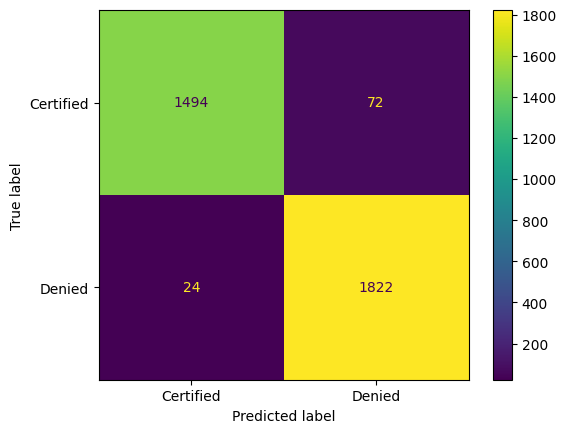

In [98]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)